In [94]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [95]:
# Check if CUDA is available
print(torch.cuda.is_available())
# Optional: Get additional GPU information
if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")

True
GPU Device Name: NVIDIA GeForce RTX 5070 Ti Laptop GPU
CUDA Version used by PyTorch: 13.0


In [96]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [97]:
print(torch.__version__)
print(torch.version.cuda)

2.13.0+cu130
13.0


In [98]:
train_df = pd.read_csv(r'/home/rahul/Projects/deep-learning-projects/convolution-fashion-classifier/data/train_data.csv')
test_df = pd.read_csv(r'/home/rahul/Projects/deep-learning-projects/convolution-fashion-classifier/data/test_data.csv')

In [99]:
print(train_df.shape)
print(test_df.shape)

(60000, 785)
(10000, 785)


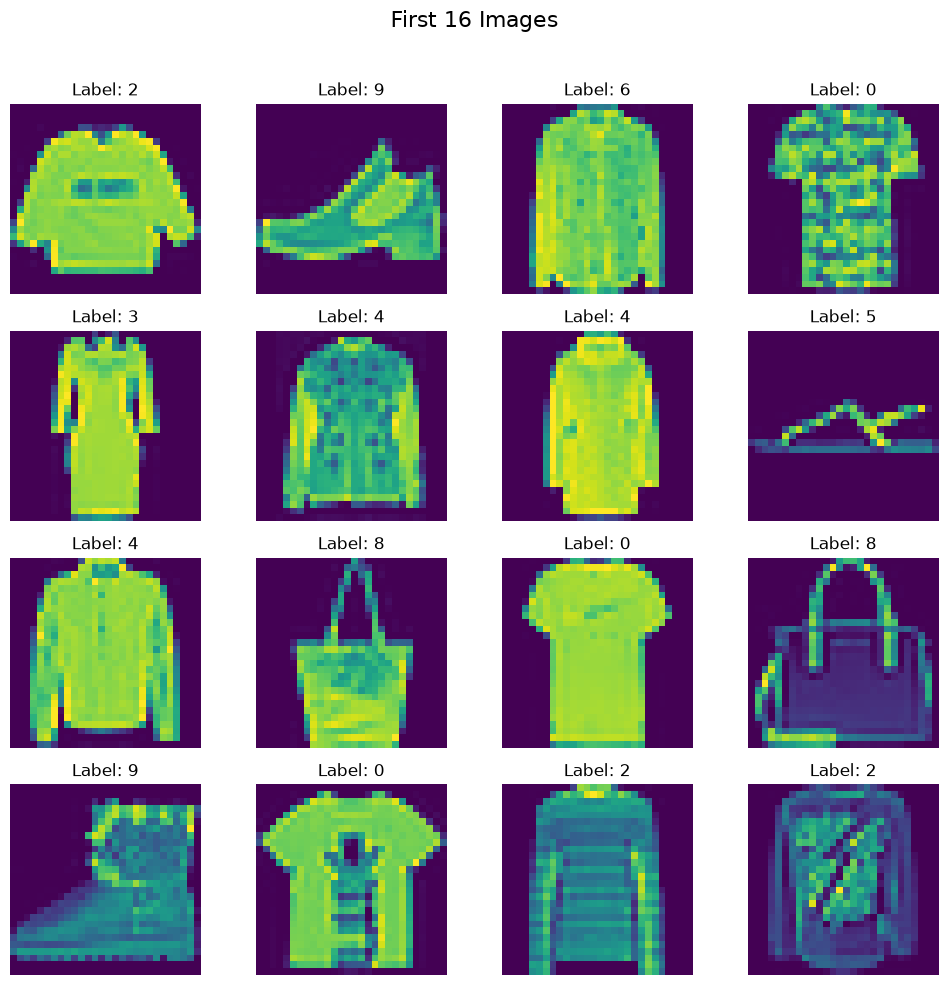

In [100]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = train_df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {train_df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [101]:
# Label is in column 0, pixels are columns 1 onward
X_train = train_df.iloc[:, 1:].to_numpy()   # pixels only
y_train = train_df.iloc[:, 0].to_numpy()    # labels only

X_test = test_df.iloc[:, 1:].to_numpy()
y_test = test_df.iloc[:, 0].to_numpy()

In [102]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [103]:
X_train = X_train / 255.0  
X_test = X_test / 255.0

In [104]:
print("Features type:", type(X_train), "Data type:", getattr(X_train, 'dtype', 'Not a NumPy array'))
print("Labels type:", type(y_train), "Data type:", getattr(y_train, 'dtype', 'Not a NumPy array'))

Features type: <class 'numpy.ndarray'> Data type: float64
Labels type: <class 'numpy.ndarray'> Data type: int64


In [105]:
data_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

In [106]:
class CustomDataset(Dataset):
    def __init__(self, features, labels, augment=False):
        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1, 1, 28, 28)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.augment = augment
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        image =  self.features[index]
        label = self.labels[index]
        
        if self.augment:
            image = data_transform(image)
        
        return image, label

In [107]:
train_dataset = CustomDataset(X_train, y_train, augment=True)
test_dataset = CustomDataset(X_test, y_test, augment=False)

In [108]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=4, persistent_workers=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers=4, persistent_workers=True)

In [109]:
class MnistCNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        
        # convolution layers
        self.features = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128)
        )
        
        # classifier layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(128*7*7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        
        return x

In [110]:
model = MnistCNN(1)
model.to(device)

MnistCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, ou

In [111]:
learning_rate1 = 0.0001 
epochs1 = 100
weight_deacy1 = 1e-4

In [112]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate1,
    weight_decay=weight_deacy1
)

In [113]:
for epoch in range(epochs1):
    model.train()
    epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        optimizer.zero_grad()        # ✅ 1. clear old gradients first

        outputs = model(batch_features)          # 2. forward pass
        loss = criterion(outputs, batch_labels)  # 3. compute loss
        loss.backward()                          # 4. backward pass
        optimizer.step()                         # 5. update weights

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

Epoch: 1, Loss: 0.8414851994037628
Epoch: 2, Loss: 0.5459038315137228
Epoch: 3, Loss: 0.47296119090716043
Epoch: 4, Loss: 0.43531881933609645
Epoch: 5, Loss: 0.40899775432745616
Epoch: 6, Loss: 0.39153788717985155
Epoch: 7, Loss: 0.3734715346813202
Epoch: 8, Loss: 0.3630745811343193
Epoch: 9, Loss: 0.3513559329966704
Epoch: 10, Loss: 0.34173131911555926
Epoch: 11, Loss: 0.3356073049505552
Epoch: 12, Loss: 0.32804238694707555
Epoch: 13, Loss: 0.32599497113227843
Epoch: 14, Loss: 0.32132573008735976
Epoch: 15, Loss: 0.3084132064839204
Epoch: 16, Loss: 0.3072939607044061
Epoch: 17, Loss: 0.3035516319990158
Epoch: 18, Loss: 0.30176016853253046
Epoch: 19, Loss: 0.2994783368120591
Epoch: 20, Loss: 0.29225040832261245
Epoch: 21, Loss: 0.2917313985367616
Epoch: 22, Loss: 0.29193686991731327
Epoch: 23, Loss: 0.28252088124553365
Epoch: 24, Loss: 0.28233367809057236
Epoch: 25, Loss: 0.28145290168921155
Epoch: 26, Loss: 0.2792132466475169
Epoch: 27, Loss: 0.275897803846995
Epoch: 28, Loss: 0.27360

In [114]:
model.eval()

MnistCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, ou

In [115]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9385666666666667


In [116]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9369


              precision    recall  f1-score   support

     T-shirt       0.90      0.90      0.90      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.93      0.89      0.91      1000
       Dress       0.94      0.95      0.94      1000
        Coat       0.87      0.93      0.90      1000
      Sandal       1.00      0.98      0.99      1000
       Shirt       0.83      0.80      0.82      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle Boot       0.97      0.97      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



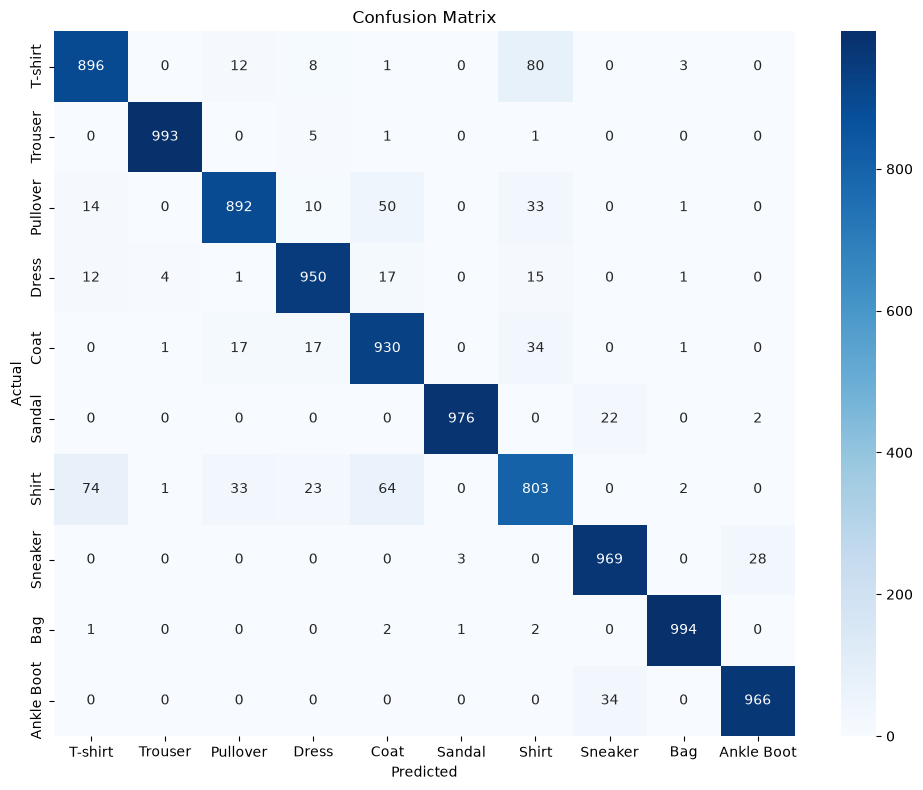

In [117]:
from sklearn.metrics import classification_report
import seaborn as sns

# Fashion-MNIST class names (optional but makes report readable)
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

model.eval()

all_preds = []    # ✅ collect all predictions
all_labels = []   # ✅ collect all true labels

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())    # move back to cpu
        all_labels.extend(batch_labels.cpu().numpy())

# ── Precision, Recall, F1 ──────────────────────────────────────
print(classification_report(all_labels, all_preds, target_names=class_names))

# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()